# 🔹 Activity 01: Data Preprocessing Pipeline

**Track:** Foundation  
**Level:** Beginner → Intermediate  
**Goal:** Build a production-ready, reusable preprocessing pipeline from scratch.

---

## 📖 What You Will Learn
- Why data preprocessing is the most critical step in any ML project
- Handling missing values (imputation strategies)
- Detecting and treating outliers
- Scaling and normalisation
- Encoding categorical variables
- Building `sklearn` Pipelines that prevent data leakage

---

## 🧠 Concept: Why Preprocess?

Raw data is messy. Machine learning models are mathematical functions that expect:
- **Numbers** – no strings, no NaN
- **Consistent scale** – a column ranging 0–1 vs 0–1,000,000 will dominate distance-based and gradient-based models
- **Meaningful representation** – "Male"/"Female" must become 0/1

> **Rule of thumb:** Garbage in → Garbage out. A well-preprocessed dataset with a simple model beats a poorly preprocessed dataset with a complex model.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


## 📊 Step 1 — Load & Inspect Data

We create a **synthetic messy dataset** that mirrors common real-world problems.

In [2]:
# ── Create a realistic messy dataset ─────────────────────────────────────────
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'age':        np.random.randint(18, 70, n).astype(float),
    'income':     np.random.exponential(50_000, n),
    'years_exp':  np.random.randint(0, 40, n).astype(float),
    'education':  np.random.choice(['High School','Bachelor','Master','PhD'], n),
    'department': np.random.choice(['Engineering','Sales','HR','Marketing'], n),
    'score':      np.random.normal(70, 15, n),
})

# Inject missingness (MCAR – missing completely at random)
for col in ['age', 'income', 'education']:
    mask = np.random.rand(n) < 0.10        # ~10 % missing
    df.loc[mask, col] = np.nan

# Inject outliers
df.loc[np.random.choice(n, 5), 'income'] = 5_000_000   # extreme high incomes

print(df.shape)
df.head()

(500, 6)


,age,income,years_exp,education,department,score
0,56.0,NaN,24.0,Master,Engineering,61.545265
1,69.0,66950.870244,25.0,Master,Engineering,63.836033
2,46.0,40411.524097,10.0,High School,Engineering,64.491637
3,32.0,47301.523602,37.0,Bachelor,HR,59.398649
4,NaN,27201.893277,1.0,PhD,Engineering,74.536746


In [13]:
# ── Exploratory check ─────────────────────────────────────────────────────────
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Data types ===')
print(df.dtypes)
print()
print('=== Descriptive stats ===')
df.describe(include='all').round(2)

=== Missing values ===
age           56
income        51
years_exp      0
education     49
department     0
score          0
dtype: int64

=== Data types ===
age           float64
income        float64
years_exp     float64
education         str
department        str
score         float64
dtype: object

=== Descriptive stats ===


,age,income,years_exp,education,department,score
count,444.00,449.00,500.00,451,500,500.00
unique,NaN,NaN,NaN,4,4,NaN
top,NaN,NaN,NaN,Bachelor,Sales,NaN
freq,NaN,NaN,NaN,123,139,NaN
mean,44.03,106342.71,20.38,NaN,NaN,69.93
std,14.95,522520.22,11.43,NaN,NaN,14.66
min,18.00,232.14,0.00,NaN,NaN,26.93
25%,32.00,14115.34,11.00,NaN,NaN,60.26
50%,44.00,35185.37,21.00,NaN,NaN,70.46
75%,56.00,73990.35,30.25,NaN,NaN,79.92


## 🔍 Step 2 — Visualise Missing Data & Distributions

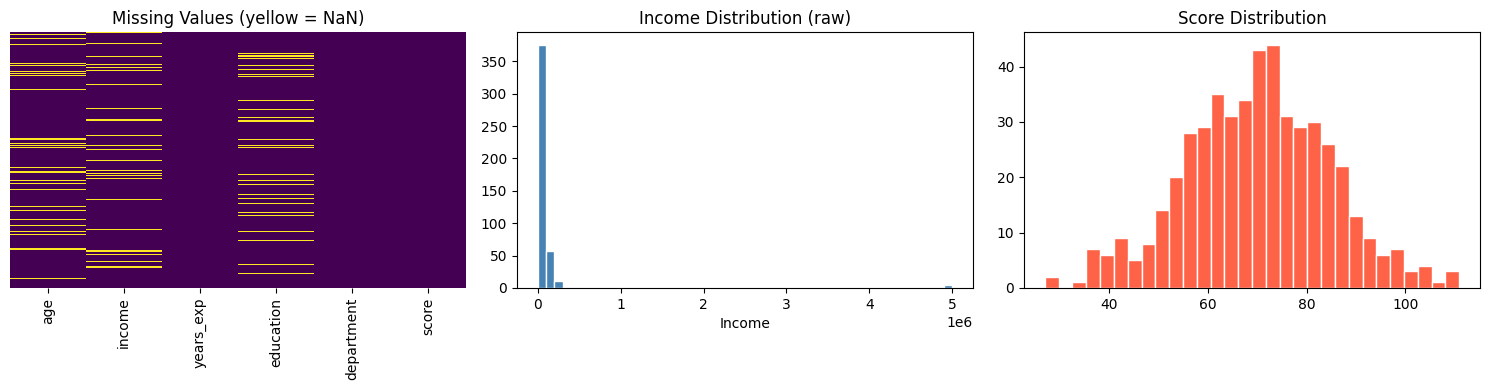

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Missing-value heatmap
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Values (yellow = NaN)')

# Income distribution — note the extreme outliers
axes[1].hist(df['income'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Income Distribution (raw)')
axes[1].set_xlabel('Income')

# Score distribution
axes[2].hist(df['score'], bins=30, color='tomato', edgecolor='white')
axes[2].set_title('Score Distribution')

plt.tight_layout()
plt.show()

## 🛠️ Step 3 — Handling Missing Values

### 🧠 Concept: Imputation Strategies

| Strategy | When to use |
|---|---|
| Mean | Numerical, roughly normal |
| Median | Numerical, skewed / outliers present |
| Mode | Categorical |
| KNN | When nearby samples share similar patterns |
| Drop | If < 1–2 % of rows affected |

> **⚠️ COMMON ERROR:** Never fit the imputer on the whole dataset before splitting. That is **data leakage** — the imputer 'sees' test data. Always fit on the training set only.

In [15]:
# ── Demonstrate imputation strategies ────────────────────────────────────────
from sklearn.impute import SimpleImputer

num_cols = ['age', 'income', 'years_exp', 'score']
cat_cols = ['education', 'department']

# Numerical: median imputation (robust to outliers)
num_imputer  = SimpleImputer(strategy='median')
df_num_imp   = pd.DataFrame(
    num_imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

# Categorical: mode imputation
cat_imputer  = SimpleImputer(strategy='most_frequent')
df_cat_imp   = pd.DataFrame(
    cat_imputer.fit_transform(df[cat_cols]),
    columns=cat_cols
)

print('Missing after numerical imputation:', df_num_imp.isnull().sum().sum())
print('Missing after categorical imputation:', df_cat_imp.isnull().sum().sum())

Missing after numerical imputation: 0
Missing after categorical imputation: 0


In [16]:
# ── KNN Imputer (more sophisticated) ─────────────────────────────────────────
# WHY: KNN uses the k nearest neighbours to estimate the missing value,
#      which respects local data structure better than global mean/median.
knn_imp = KNNImputer(n_neighbors=5)
df_knn  = pd.DataFrame(
    knn_imp.fit_transform(df[num_cols]),
    columns=num_cols
)
print('Missing after KNN imputation:', df_knn.isnull().sum().sum())
print(df_knn.describe().round(2))

Missing after KNN imputation: 0
          age      income  years_exp   score
count  500.00      500.00     500.00  500.00
mean    43.90   116671.53      20.38   69.93
std     14.18   508993.67      11.43   14.66
min     18.00      232.14       0.00   26.93
25%     33.00    16399.67      11.00   60.26
50%     44.00    38513.64      21.00   70.46
75%     55.00    76832.57      30.25   79.92
max     69.00  5000000.00      39.00  110.96


## 📐 Step 4 — Scaling & Normalisation

### 🧠 Concept: Which Scaler?

| Scaler | Formula | When to use |
|---|---|---|
| StandardScaler | (x − μ) / σ | Data roughly normal; good default |
| MinMaxScaler | (x − min) / (max − min) → [0,1] | Neural networks; no outliers |
| RobustScaler | (x − median) / IQR | Heavy outliers present |

> **⚠️ COMMON ERROR:** Scaling before splitting leaks test-set statistics into training.

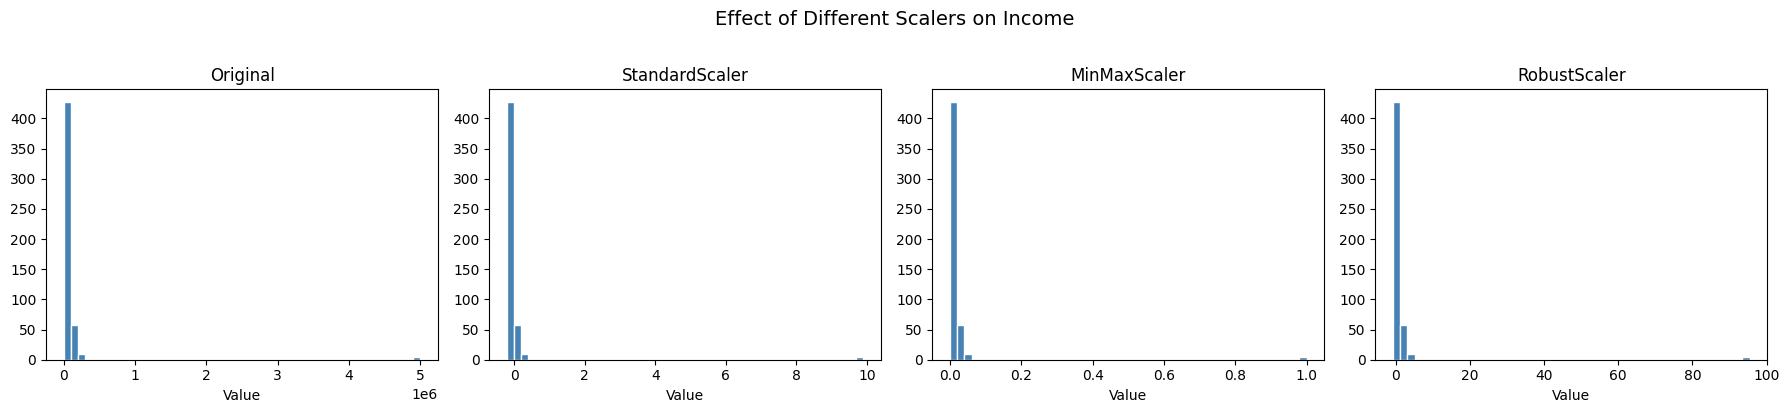

In [17]:
# ── Compare scalers visually ─────────────────────────────────────────────────
sample_income = df_num_imp['income'].values.reshape(-1, 1)

scalers = {
    'Original':     sample_income,
    'StandardScaler': StandardScaler().fit_transform(sample_income),
    'MinMaxScaler':   MinMaxScaler().fit_transform(sample_income),
    'RobustScaler':   RobustScaler().fit_transform(sample_income),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(name)
    ax.set_xlabel('Value')
plt.suptitle('Effect of Different Scalers on Income', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 🏷️ Step 5 — Encoding Categorical Variables

### 🧠 Concept: Encoding Strategies

| Method | Use case | Pitfall |
|---|---|---|
| Label Encoding | Ordinal categories | Creates false numeric ordering for nominal |
| One-Hot Encoding | Nominal, low cardinality | Dummy trap if `drop` not set |
| Ordinal Encoding | Truly ordered categories | Requires correct ordering |
| Target Encoding | High cardinality | **Data leakage** risk — must use CV-safe variant |

In [18]:
# ── One-Hot Encoding ──────────────────────────────────────────────────────────
ohe = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy trap
dept_encoded = pd.DataFrame(
    ohe.fit_transform(df_cat_imp[['department']]),
    columns=ohe.get_feature_names_out(['department'])
)
print('One-Hot Encoded Department:')
print(dept_encoded.head())

# ── Ordinal Encoding ──────────────────────────────────────────────────────────
# WHY: Education has a natural ordering; ordinal encoding respects this.
edu_order = [['High School', 'Bachelor', 'Master', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
edu_encoded = oe.fit_transform(df_cat_imp[['education']])
print('\nOrdinal Encoded Education (first 5):', edu_encoded[:5].flatten())

One-Hot Encoded Department:
   department_HR  department_Marketing  department_Sales
0            0.0                   0.0               0.0
1            0.0                   0.0               0.0
2            0.0                   0.0               0.0
3            1.0                   0.0               0.0
4            0.0                   0.0               0.0

Ordinal Encoded Education (first 5): [2. 2. 0. 1. 3.]


## 🏗️ Step 6 — Building the Full sklearn Pipeline

### 🧠 Concept: Why Pipelines?

A Pipeline:
1. **Prevents data leakage** — transformers are fit only on training data, even inside CV
2. **Simplifies code** — one call to `fit()` and `predict()`
3. **Deployment-ready** — save the entire pipeline as a single object

```
Raw data ──► Impute ──► Scale ──► Encode ──► Model
                 ↑___________fit on train only___↑
```

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Target: predict 'score'
X = df.drop(columns=['score'])
y = df['score']

num_features = ['age', 'income', 'years_exp']
cat_features = ['education', 'department']

# ── Sub-pipelines ─────────────────────────────────────────────────────────────
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
])

# ── ColumnTransformer: apply sub-pipelines to the correct columns ─────────────
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,    num_features),
    ('cat', categorical_pipeline, cat_features),
])

# ── Full pipeline with a model at the end ─────────────────────────────────────
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression()),
])

print('Pipeline constructed:')
print(full_pipeline)

Pipeline constructed:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'income',
                                                   'years_exp']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='fi

In [10]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Fit on training data ONLY ─────────────────────────────────────────────────
# WHY: The pipeline automatically fits all transformers on X_train
#      and then applies the fitted transforms to X_test — zero data leakage.
full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.4f}')

RMSE : 14.780
R²   : 0.0095


## 🔍 Step 7 — Outlier Detection & Treatment

Outlier bounds: [-75,697, 163,803]
Number of outliers: 24
Outlier values: [5000000.         5000000.          232850.24450701  215772.9281029
  213438.6969801   165143.5053126   175126.34614397  247841.4303963
  174178.7610628   183248.00612613  214193.27877763  218213.77341101
 5000000.          175185.4277188   408622.2798909   284743.67003722
  195682.65487903 5000000.          201932.1083008   174452.98320634
  230060.06556977  167658.81947078 5000000.          209458.69945604]


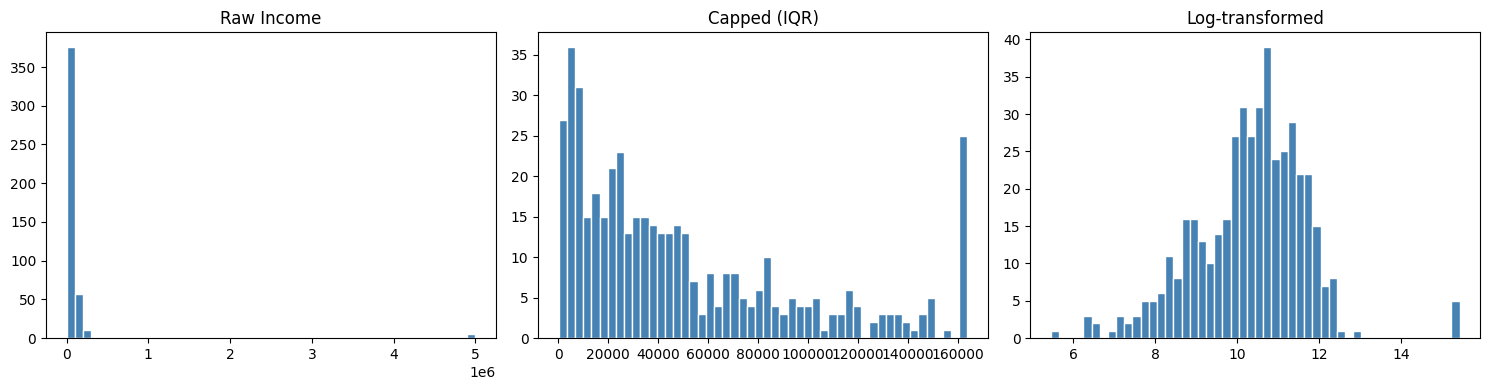

In [11]:
# ── IQR method ────────────────────────────────────────────────────────────────
# WHY: IQR is robust; the mean-based Z-score method is itself influenced by outliers.
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

income_clean = df['income'].dropna()
lo, hi = iqr_bounds(income_clean)
outliers = income_clean[(income_clean < lo) | (income_clean > hi)]
print(f'Outlier bounds: [{lo:,.0f}, {hi:,.0f}]')
print(f'Number of outliers: {len(outliers)}')
print(f'Outlier values: {outliers.values}')

# Treatment options:
# 1. Cap (Winsorize)
income_capped = income_clean.clip(lower=lo, upper=hi)
# 2. Log transform (reduces magnitude of extreme values)
income_log = np.log1p(income_clean)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
    [income_clean, income_capped, income_log],
    ['Raw Income', 'Capped (IQR)', 'Log-transformed']):
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## ✅ Step 8 — Save the Pipeline

In [12]:
import joblib, os

os.makedirs('models', exist_ok=True)
joblib.dump(full_pipeline, 'models/preprocessing_pipeline.pkl')
print('✅ Pipeline saved to models/preprocessing_pipeline.pkl')

# Reload and verify
loaded = joblib.load('models/preprocessing_pipeline.pkl')
y_pred_reloaded = loaded.predict(X_test)
assert np.allclose(y_pred, y_pred_reloaded), 'Mismatch after reload!'
print('✅ Pipeline reloaded and predictions match')

✅ Pipeline saved to models/preprocessing_pipeline.pkl
✅ Pipeline reloaded and predictions match


## 🎯 Summary

| Step | Technique | Key Takeaway |
|---|---|---|
| Missing Values | Median/Mode/KNN imputation | Never impute before splitting |
| Scaling | StandardScaler / RobustScaler | Scale after splitting |
| Encoding | OHE / Ordinal | Drop first column → no dummy trap |
| Pipeline | `sklearn.Pipeline` + `ColumnTransformer` | One object, zero leakage |
| Outliers | IQR capping / log-transform | RobustScaler handles residual outliers |

---

**Next:** [02_feature_engineering_basic.ipynb](02_feature_engineering_basic.ipynb)